In [31]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import special
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy import signal
from scipy.fft import fftshift

import networkx as nx

%matplotlib inline
plt.style.use('seaborn-bright')

C:\Users\kgaya\AppData\Local\Temp\ipykernel_35636\2486933572.py:16: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-bright')


In [32]:
# (1) Connectivity and Inputs

T = 50000   # Time scale (au)
dt = 0.1    # Integration time step
N = 4       # Network size
pop_size = 1000 # Subpopulation size TODO: Should this be varied for different nodes as well?

gamma = 0.016       # Conversion parameter to mV
wee = 1.6 / gamma   # E -> E subpopulation synaptic weight  
wei = 3 / gamma     # I -> E subpopulation synaptic weight
wie = -4.7 / gamma  # E -> I subpopulation synaptic weight
wii = -0.13 / gamma # I -> I subpopulation synaptic weight
tau_e = 1           # Time scale for E subpopulation
tau_i = 1 / 2       # Time scale for I subpopulation

beta = 300 * gamma  # slope of firing function

e_bias = -0.25 / gamma  # Bias for E subpopulation
i_bias = -0.5 / gamma   # Bias for I subpopulation

# Neural dynamic heterogeneity parameters | TODO: Can we use a uniform sampling between 2.5 to 16.25?
Sig_e = np.array([7.8, 7.8, 2.5, 7.8])
Sig_i = np.array([9.25, 16.25, 12.25, 10.0])
D = 0.000 / (gamma ** 2)

# Synaptic Weights
rho = 1.0           # Connectivity prob
prop = 0.8          # subpopulation proportion
sigma_K = 0.005     # variance of coupling weights
mu_K = 0.08         # mean of coupling weights

In [33]:
W = np.zeros((N, N))
K = np.random.normal(mu_K, np.sqrt(sigma_K), size = (N, N))

_temp = np.zeros(N)
for i in range(N):
  for j in range(N):
    P_connectivity = np.random.rand()
    if (P_connectivity < rho):
        _temp[j] = K[i][j]
    else:
        _temp[j] = 0
  np.random.shuffle(_temp)  

  for j in range(N):
    if i !=j :
      W[i][j] = _temp[j]

if N > 2:
    row_sum = np.zeros(N)
    for i in range(N):
      row_sum[i] = np.sum( W[i][:] )
      number_of_nonzero_entries = (W[i, :] != 0).sum(0)

      for j in range(N):
        if W[i][j] !=  0:  
          W[i][j] -= row_sum[i] / number_of_nonzero_entries

In [34]:
# Environmental perturbations
perturbations = np.zeros(T)
filtered_noise_1 = np.zeros(T)
filtered_noise_2 = np.zeros(T)
filtered_noise_3 = np.zeros(T)
Noise = 0.05
for t in range(T - 1):
  perturbations[t + 1] = perturbations[t] + dt * (-perturbations[t] + filtered_noise_1[t])
  filtered_noise_1[t + 1] = filtered_noise_1[t] + dt * 0.1 * (-filtered_noise_1[t] + filtered_noise_2[t])
  filtered_noise_2[t + 1] = filtered_noise_2[t] + dt * 0.1 * (-filtered_noise_2[t] + filtered_noise_3[t])
  filtered_noise_3[t + 1] = filtered_noise_3[t] + dt * -filtered_noise_3[t] \
                            + np.sqrt(2 * Noise * dt) * np.random.normal(0, 1)

In [35]:
# (2) Network Dynamics

ue = np.zeros((N, T))
ui = np.zeros((N, T))

# resonse function of neurons
def f(x, beta, thresh):
    return 1 / (1 + np.exp(-beta * (x - thresh)))

def F(x, beta, thresh, gamma, sig):
    vmin = -1 / gamma; vmax = 1 / gamma; nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    if type(x) == np.ndarray and len(x.shape) == 4:
        x = np.repeat(x[:, :, :, :, np.newaxis], nsteps, axis=4)
    sigmoid_vals = f(x + v, beta, thresh)
    normal_vals = np.exp(-v ** 2 / (2 * sig ** 2)) / np.sqrt(2 * np.pi * sig ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

# TODO: Can we have heterogeneity in mean firing thresh for each population?
thresh_e_sig = 0.0      # mean firing threshold for E-subpopulation
thresh_i_sig = 0.0      # mean firing threshold for I-subpopulation

thresh_e = np.zeros(N)
thresh_i = np.zeros(N)

#Euler integration
for i in range(N):
  ue[i][0] = 0.05 * np.random.normal(0, 1)
  ui[i][0] = 0.05 * np.random.normal(0, 1)
  
  thresh_e[i] = np.sqrt(thresh_e_sig) * np.random.normal(0,1)
  thresh_i[i] = np.sqrt(thresh_i_sig) * np.random.normal(0,1)

for t in range(T - 1):
  for i in range(N):
    _sum_e = 0; _sum_i = 0
    for j in range(N):
        _sum_e += W[i][j] * ue[j][t]
        
    _sum_e += wee * F(ue[i][t], beta, thresh_e[i], gamma, Sig_e[i]) \
              + wie * F(ui[i][t], beta, thresh_i[i], gamma, Sig_i[i])
    
    if i == 0:
        _sum_e += perturbations[t] / gamma
        
    ue[i][t + 1] = ue[i][t] + dt / tau_e * (-ue[i][t] + _sum_e + e_bias) \
                   + np.sqrt(2 * D * dt) * np.random.normal(0, 1)
    
    _sum_i += wei * F(ue[i][t], beta, thresh_e[i], gamma, Sig_e[i]) \
              + wii * F(ui[i][t], beta, thresh_i[i], gamma, Sig_i[i])
    ui[i][t + 1] = ui[i][t] + dt / tau_i * (-ui[i][t] + _sum_i + i_bias) \
                   + np.sqrt(2 * D * dt) * np.random.normal(0, 1)


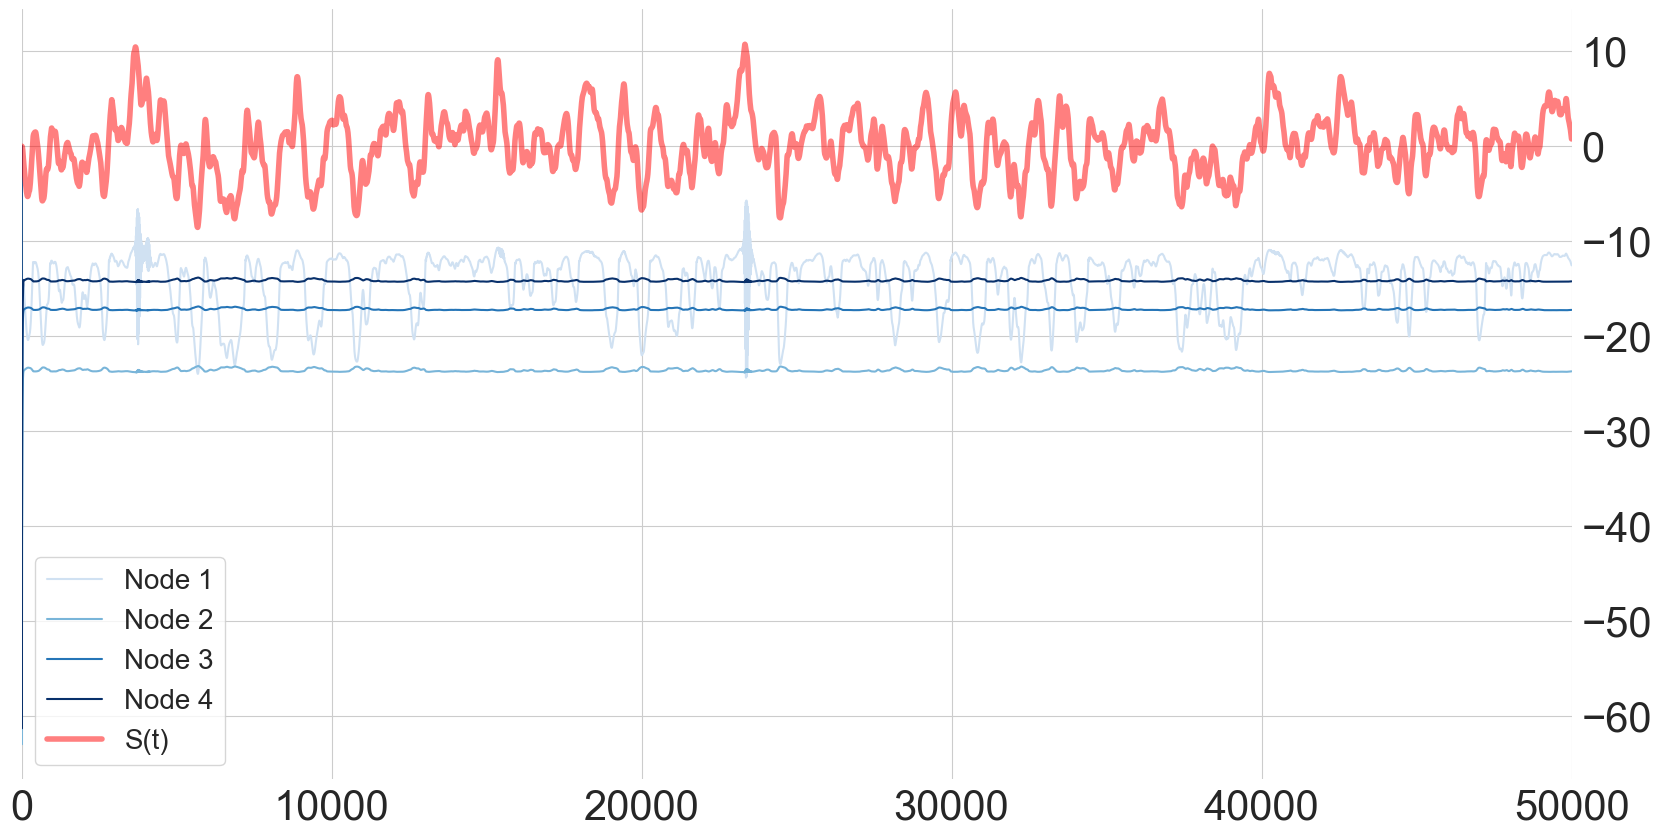

In [36]:
# 5 Visualization in time and Lyapunov exponents

time = np.arange(0, T, 1)
plt.figure(figsize=(20,10))
colormap = plt.cm.gist_ncar
plt.rcParams.update({'font.size': 30})
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, N))))
for i in range(N):
    plt.plot(time, ue[i][:], label = f'Node {i+1:01d}')

plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.plot(time, perturbations / gamma, color='red',  linewidth=4, alpha=0.5, label = 'S(t)')
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.legend(loc = 'lower left', fontsize=20)
plt.xlim(0, T) 
plt.show()

C:\Users\kgaya\AppData\Local\Temp\ipykernel_35636\3378939155.py:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2, 1, 1)


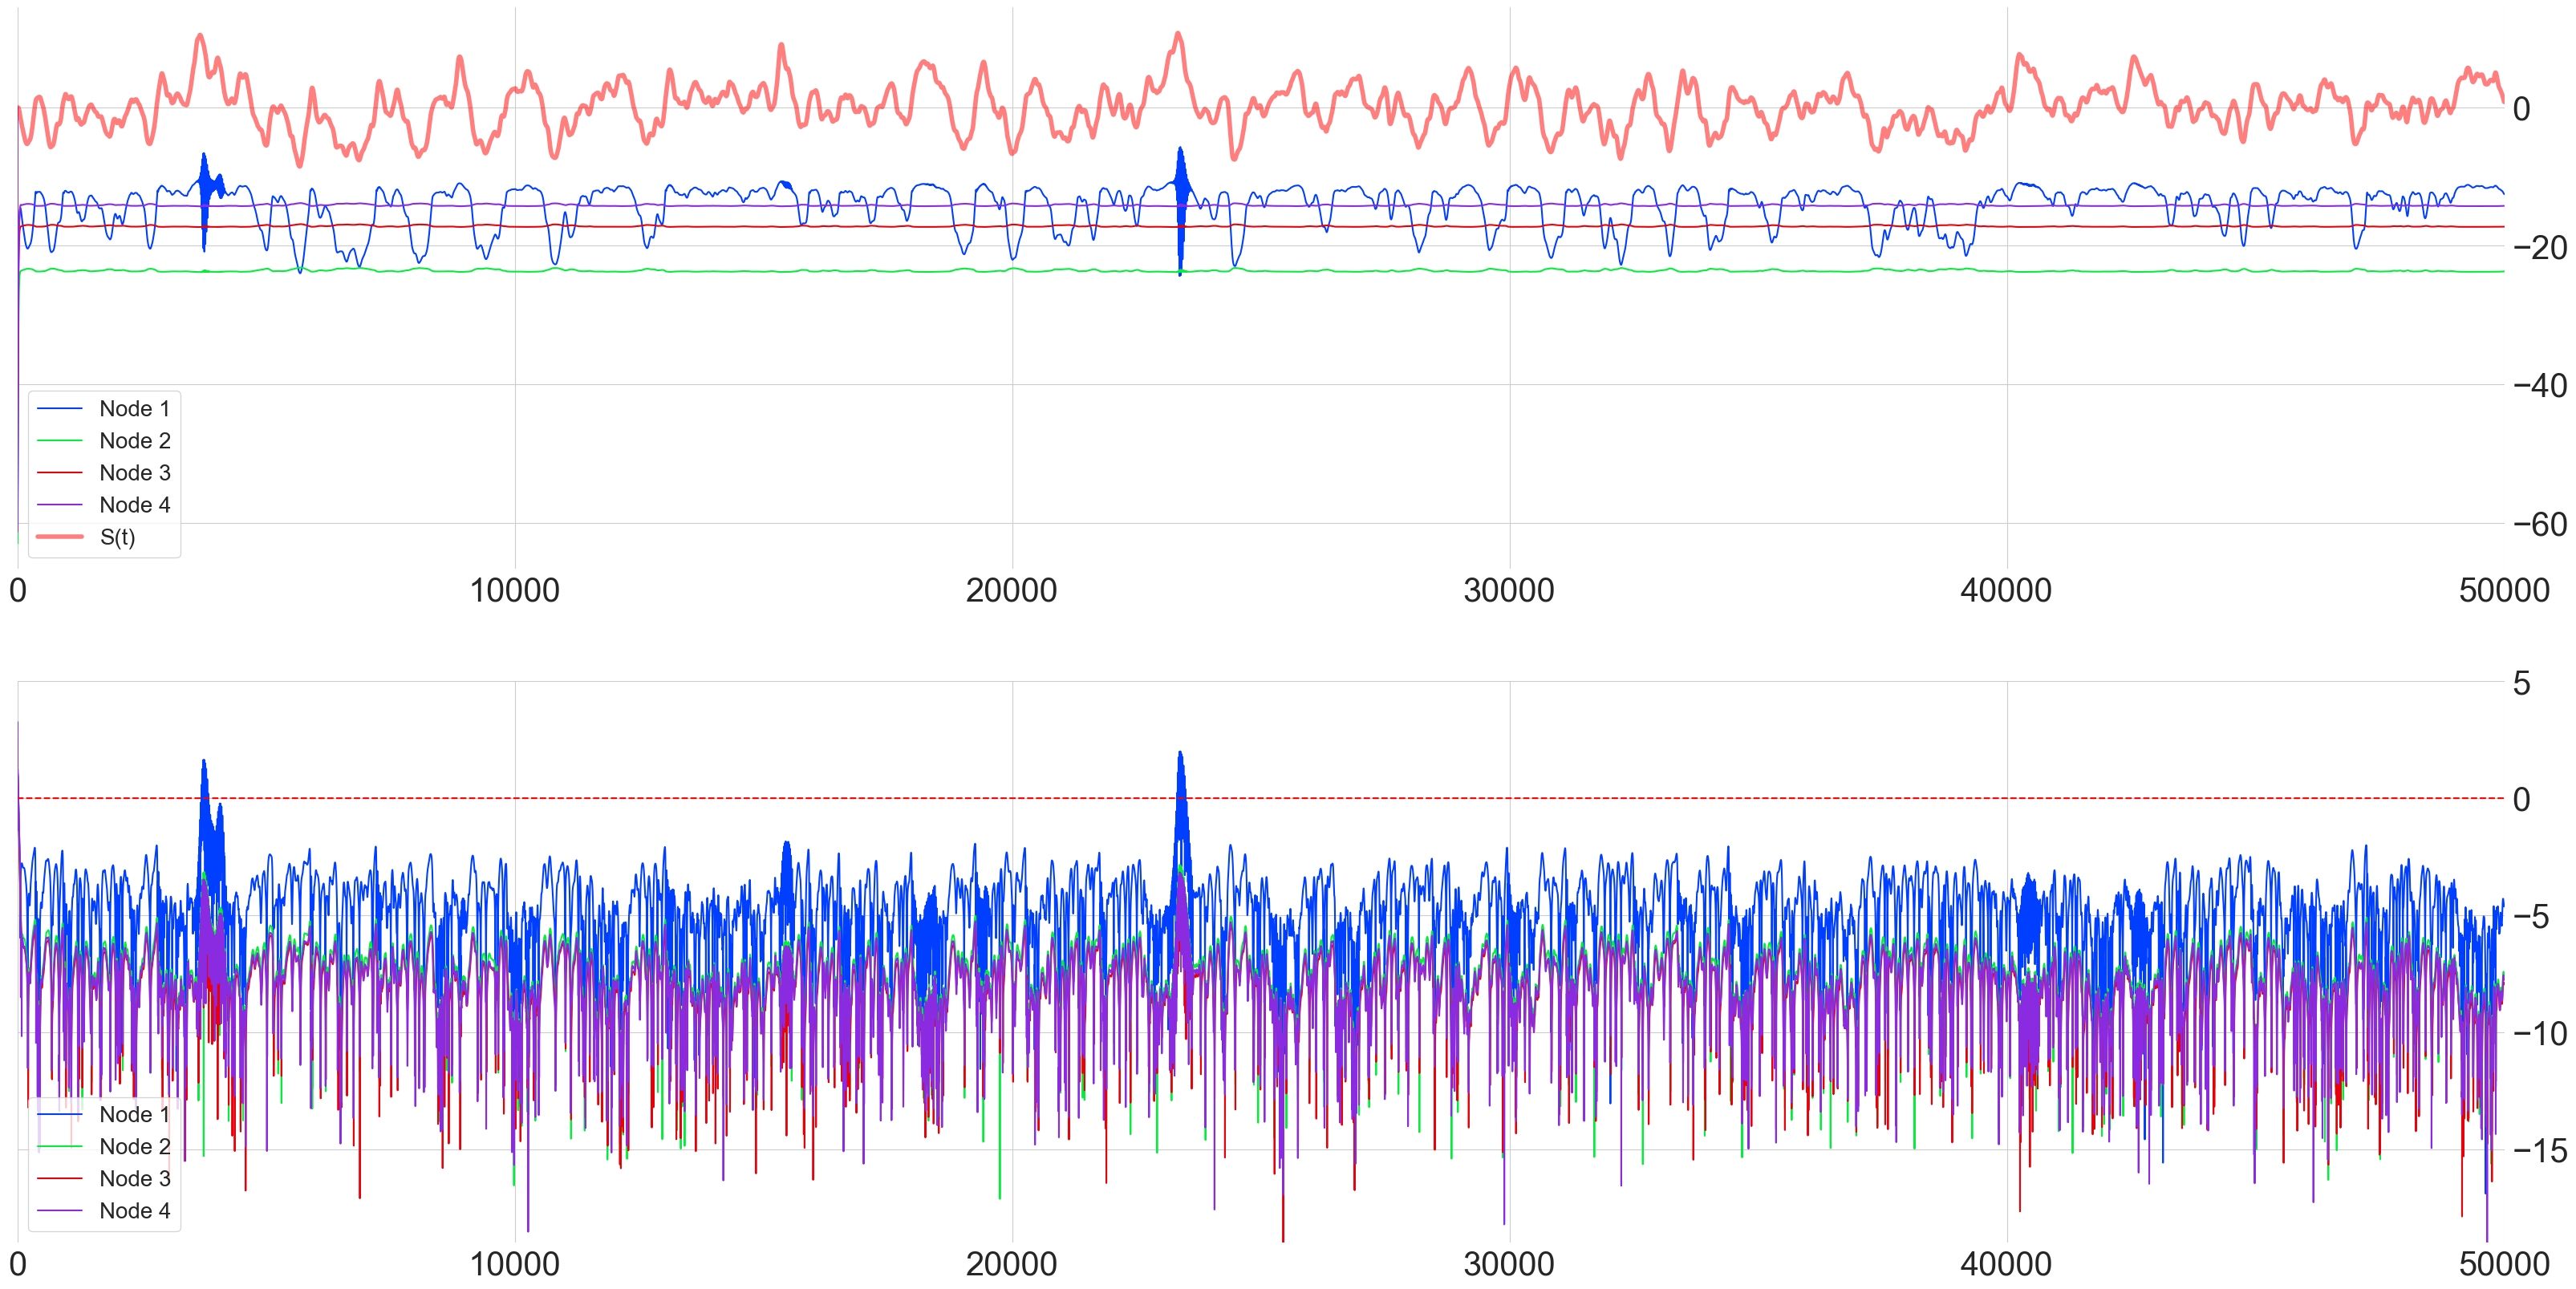

In [37]:
colormap = plt.cm.gist_ncar
plt.figure(figsize=(40,20))
plt.rcParams.update({'font.size': 30})
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, N))))

plt.subplot(2, 1, 1)
for i in range(N):
    plt.plot(time, ue[i][:], label = f'Node {i+1:01d}')

plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.plot(time, perturbations / gamma, color='red',  linewidth=4, alpha=0.5, label = 'S(t)')
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
plt.legend(loc = 'lower left', fontsize=20)
plt.xlim(0, T) 

t_prime = time[: T - 1]
plt.subplot(2, 1, 2)
for i in range(N):
  plt.plot(t_prime, np.log(np.abs(np.diff((ue[i][0 : T])))), label = f'Node {i+1:01d}')
plt.plot(t_prime,np.zeros(T - 1),"--", color='red')
for pos in ['right', 'top', 'bottom', 'left']:
   plt.gca().spines[pos].set_visible(False)
plt.tick_params(axis='y', which='both', labelleft=False, labelright=True) 
plt.ylim(-19, 5)
plt.xlim(0, T) 
plt.legend(loc = 'lower left', fontsize = 20)

[[ 0.         -0.01887839  0.00552355  0.01335484]
 [-0.04967317  0.          0.0404064   0.00926677]
 [-0.03055234 -0.00059421  0.          0.03114655]
 [-0.03628566 -0.00523717  0.04152283  0.        ]]


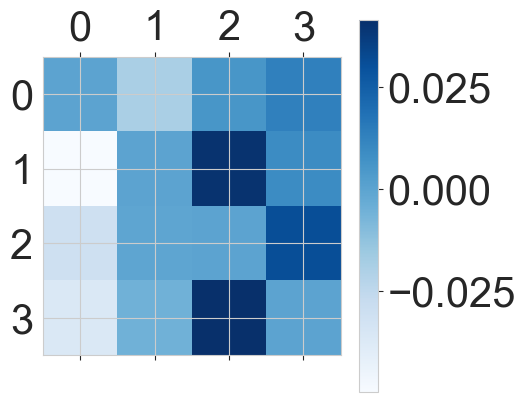

In [38]:
plt.matshow(W, cmap = plt.cm.Blues)
plt.colorbar()
print(W)

C:\Users\kgaya\AppData\Local\Temp\ipykernel_35636\2812500369.py:4: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(N + 1, 1, 1)


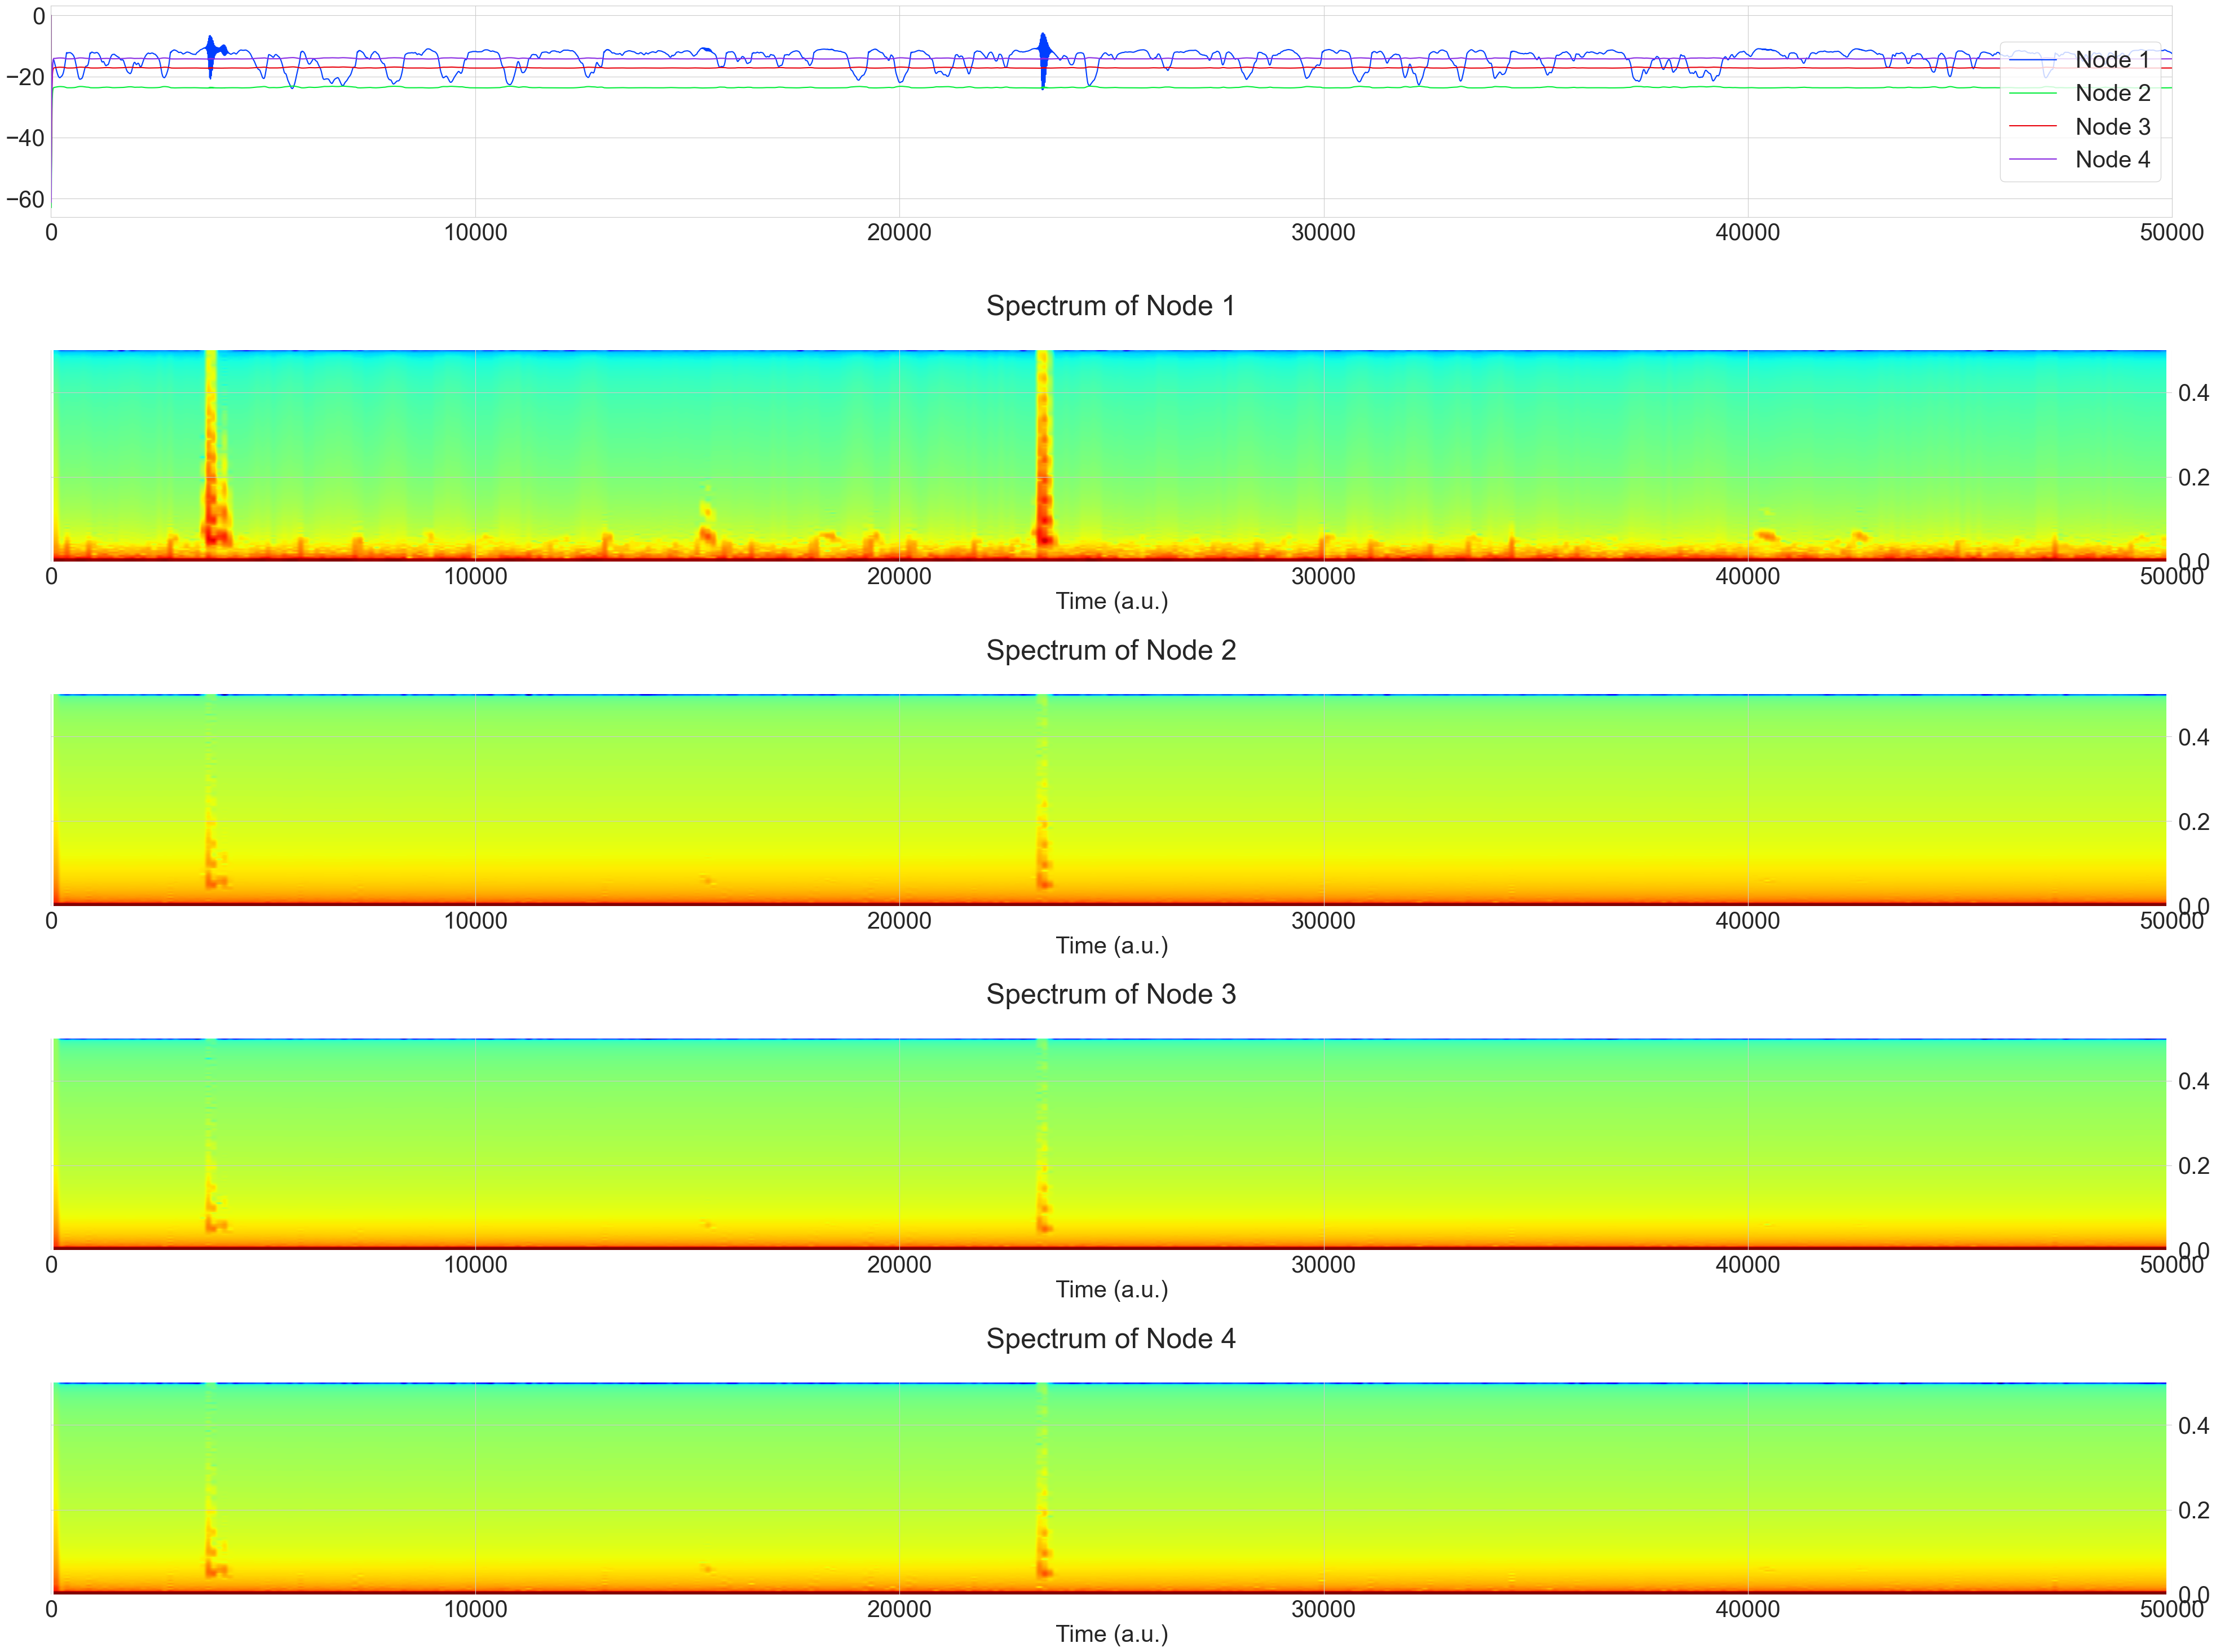

In [39]:
plt.figure(figsize=(40,30))
plt.rcParams.update({'font.size': 30})
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Blues(np.linspace(0.2, 1, N))))
plt.subplot(N + 1, 1, 1)
for i in range(N):
    plt.plot(time, ue[i][:], label = f'Node {i+1:01d}')
plt.xlim(0, T) 
plt.legend(loc = 'right')

for k in range(N):
    plt.subplot(N + 1, 1, k + 2)
    plt.specgram(ue[k][:], Fs=1, cmap='jet')
    for pos in ['right', 'top', 'bottom', 'left']:
       plt.gca().spines[pos].set_visible(False)
    plt.tick_params(axis='y', which='both', labelleft=False, labelright=True)
    plt.xlabel('Time (a.u.)')
    plt.xlim(0, T) 
    plt.title(f'Spectrum of Node {k + 1:01d}\n')
plt.tight_layout()
plt.show()